In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_=pd.read_csv('../../../data/processed/RNA/Deconvoluted_cell_types.csv', index_col=0)

In [3]:
df_=df_.T

In [4]:
mdata=pd.DataFrame(index=df_.index.values)
mdata['Time']=[i.split('-')[-1] for i in mdata.index.values]
mdata['Cohort']=[i.split('-')[1][1] for i in mdata.index.values]
mdata['Subject']=[i.split('-')[1] for i in mdata.index.values]

In [6]:
topics=pd.read_excel('../../../data/processed/clinical/Subjects_data.xlsx', index_col=0)
topics.index=topics.index.astype(str)

In [7]:
mdata=mdata[mdata.Time=='B'].merge(topics[['Hyper_DCABP_general']], left_on='Subject', right_index=True).dropna()

In [8]:
df_=df_.merge(mdata[['Hyper_DCABP_general']], left_index=True, right_index=True)

# Compare abundances across Hyper DCABPs

In [9]:
import pandas as pd
import numpy as np
from scipy.stats import shapiro, ttest_ind, mannwhitneyu
from statsmodels.stats.multitest import multipletests




In [10]:
def compare_features_across_groups(
    df,
    alpha=0.05,
    normality_alpha=0.05
):
    """
    Compare all features across two groups (last column = group).

    Returns a DataFrame with test results.
    """

    group_col = df.columns[-1]
    feature_cols = df.columns[:-1]

    groups = df[group_col].unique()
    if len(groups) != 2:
        raise ValueError("Exactly two groups are required.")

    g1, g2 = groups
    results = []

    for feature in feature_cols:
        x1 = df[df[group_col] == g1][feature].dropna()
        x2 = df[df[group_col] == g2][feature].dropna()

        # Skip constant features
        if x1.nunique() <= 1 and x2.nunique() <= 1:
            continue

        # Normality tests (only if enough samples)
        normal1 = shapiro(x1)[1] > normality_alpha if len(x1) >= 3 else False
        normal2 = shapiro(x2)[1] > normality_alpha if len(x2) >= 3 else False

        if normal1 and normal2:
            stat, pval = ttest_ind(x1, x2, equal_var=False)
            test = "Welch t-test"
        else:
            stat, pval = mannwhitneyu(x1, x2, alternative="two-sided")
            test = "Mann-Whitney U"

        results.append({
            "feature": feature,
            "test": test,
            "statistic": stat,
            "p_value": pval,
            "mean_group_1": x1.mean(),
            "mean_group_2": x2.mean()
        })

    results_df = pd.DataFrame(results)

    # Multiple testing correction
    corrected = multipletests(results_df["p_value"], alpha=alpha, method="fdr_bh")
    results_df["p_adj"] = corrected[1]
    results_df["significant"] = corrected[0]

    return results_df.sort_values("p_adj")

In [11]:
test_=compare_features_across_groups(df_)

# Panel F

In [12]:
df=test_.copy()
df['log2FC']=np.log2(df['mean_group_1']/df['mean_group_2'])

In [13]:
df['color']='blue'
df.loc[df.p_adj<0.05,'color']='red'
df.loc[(df.p_adj>0.05) & (df.p_adj<0.2),'color']='orange'
# Sort for nicer display
df = df.sort_values('log2FC')



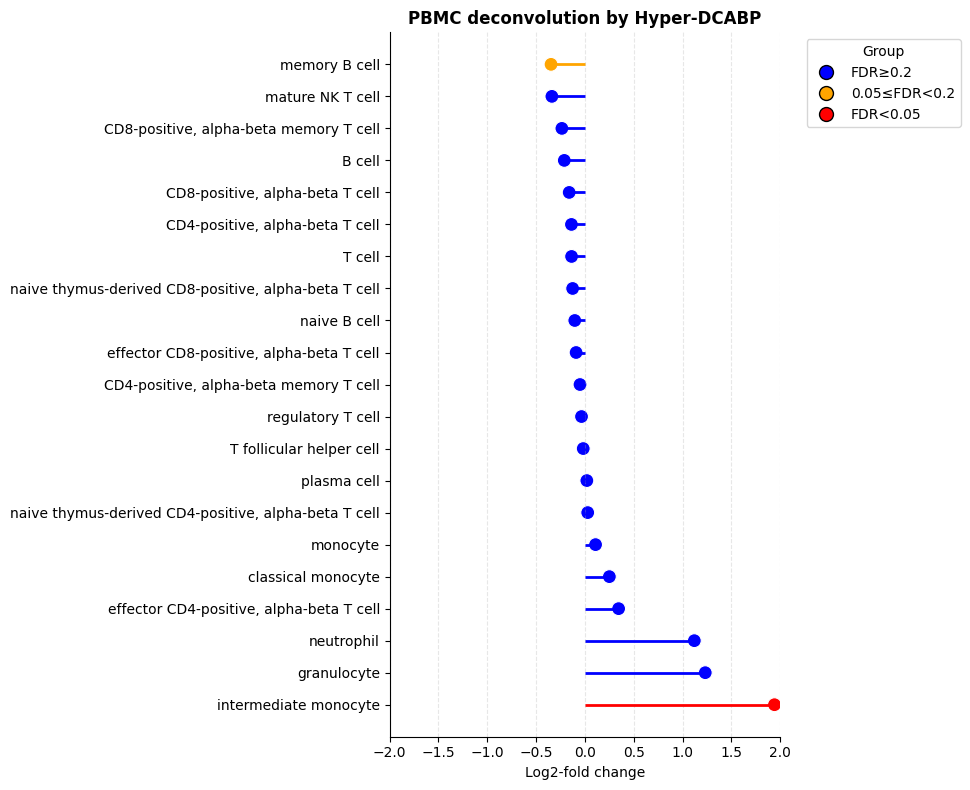

In [14]:
from matplotlib.lines import Line2D
# Create figure
plt.figure(figsize=(10,8))

# Draw lines
plt.hlines(
    y=df['feature'],
    xmin=0,
    xmax=df['log2FC'],
    color=df['color'],
    linewidth=2
)

# Draw points
sns.scatterplot(
    df,
    y='feature',
    x='log2FC',
    s=100,
    color=df['color']
)


# ---- Create legend manually ----

# Example: define what each color means
color_labels = {
    "blue": "FDR≥0.2",
    "orange": "0.05≤FDR<0.2",
    "red": "FDR<0.05"
}

legend_elements = [
    Line2D([0], [0],
           marker='o',
           color='w',
           label=label,
           markerfacecolor=color,
           markeredgecolor='black',
           markersize=10)
    for color, label in color_labels.items()
]

plt.legend(
    handles=legend_elements,
    title="Group",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)


plt.xlim([-2,2])
# Style
plt.title("PBMC deconvolution by Hyper-DCABP", fontweight='bold')
plt.xlabel("Log2-fold change")
plt.ylabel("")
plt.grid(axis='x', linestyle='--', alpha=0.3)

sns.despine()

plt.tight_layout()
#plt.savefig('lollipop.svg')

# Panel G

In [15]:
from scipy.stats import mannwhitneyu

def p_to_stars(p):
    if p < 0.0001: return "****"
    if p < 0.001:  return "***"
    if p < 0.01:   return "**"
    if p < 0.05:   return "*"
    return "ns"
 
def coerce_binary(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (bool, np.bool_)):
        return int(x)
    if isinstance(x, (int, float, np.integer, np.floating)) and x in [0, 1]:
        return int(x)
    s = str(x).strip().lower()
    if s in ["1", "true", "yes", "y", "early", "early pd", "early progression"]:
        return 1
    if s in ["0", "false", "no", "n", "non-early", "not early", "non early", "late", "non-early pd"]:
        return 0
    try:
        return int(float(s))
    except:
        return np.nan
 
def summarize(x):
    x = np.asarray(x, dtype=float)
    mean = np.mean(x)
    sd = np.std(x, ddof=1) if len(x) > 1 else np.nan
    med = np.median(x)
    q1 = np.quantile(x, 0.25)
    q3 = np.quantile(x, 0.75)
    return mean, sd, med, q1, q3
 
def cliffs_delta(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    gt = 0
    lt = 0
    for xi in x:
        gt += np.sum(xi > y)
        lt += np.sum(xi < y)
    n = len(x) * len(y)
    return (gt - lt) / n
 
def violin_compare(df, early_series, value_series, y_label, title, out_prefix):
    tmp = pd.DataFrame({"early": early_series, "val": value_series}).dropna()
    
    g1 = tmp.loc[tmp["early"] == 1, "val"].to_numpy()
    g0 = tmp.loc[tmp["early"] == 0, "val"].to_numpy()
 
    print("\n" + "="*80)
    print(title)
 
    m1, sd1, med1, q11, q31 = summarize(g1)
    m0, sd0, med0, q10, q30 = summarize(g0)
 
    u_stat, p_val = mannwhitneyu(g1, g0, alternative="two-sided", method="asymptotic")
    stars = p_to_stars(p_val)
 
    print(f"  Mann–Whitney p={p_val:.4g} ({stars})")
 
    # Plot
    fig, ax = plt.subplots(figsize=(4.8, 5.2), dpi=200)
 
    data = [g1, g0]
    positions = [1, 2]
    vp = ax.violinplot(data, positions=positions, widths=0.8,
                       showmeans=False, showmedians=True, showextrema=False)
    for b in vp['bodies']:
        b.set_alpha(0.25)
    vp['cmedians'].set_linewidth(2)
 
    rng = np.random.default_rng(42)
    for i, y in enumerate(data):
        x = np.full_like(y, positions[i], dtype=float)
        jitter = rng.normal(0, 0.06, size=len(y))
        ax.scatter(x + jitter, y, s=14, alpha=0.7)
 
    ax.set_xticks(positions)
    ax.set_xticklabels(["U-DCABP", "F-DCABP"])
    ax.set_ylabel(y_label)
    ax.set_title(title)
 
    # p-value bracket
    y_all = np.concatenate(data)
    y_max = float(np.max(y_all))
    y_min = float(np.min(y_all))
    y_range = y_max - y_min if y_max > y_min else 1.0
    bar_y = y_max + 0.08 * y_range
    bar_h = 0.03 * y_range
 
    ax.plot([1, 1, 2, 2], [bar_y, bar_y + bar_h, bar_y + bar_h, bar_y], lw=1.5)
    ax.text(1.5, bar_y + bar_h + 0.02 * y_range, stars, ha="center", va="bottom", fontsize=12)
    #ax.text(1.5, bar_y + bar_h + 0.002 * y_range, f"p={p_val:.2e}", ha="center", va="bottom", fontsize=8)
    #ax.text(1.5, bar_y + bar_h + 0.06 * y_range, f"Cliff’s δ={cd:.2f}", ha="center", va="bottom", fontsize=9)
 
    ax.set_ylim(y_min - 0.1 * y_range, bar_y + bar_h + 0.14 * y_range)
    import seaborn as sns
    sns.despine()
    plt.tight_layout()
#   fig.savefig(out_prefix + ".svg", bbox_inches="tight")
    plt.show()



  Mann–Whitney p=0.0009181 (***)


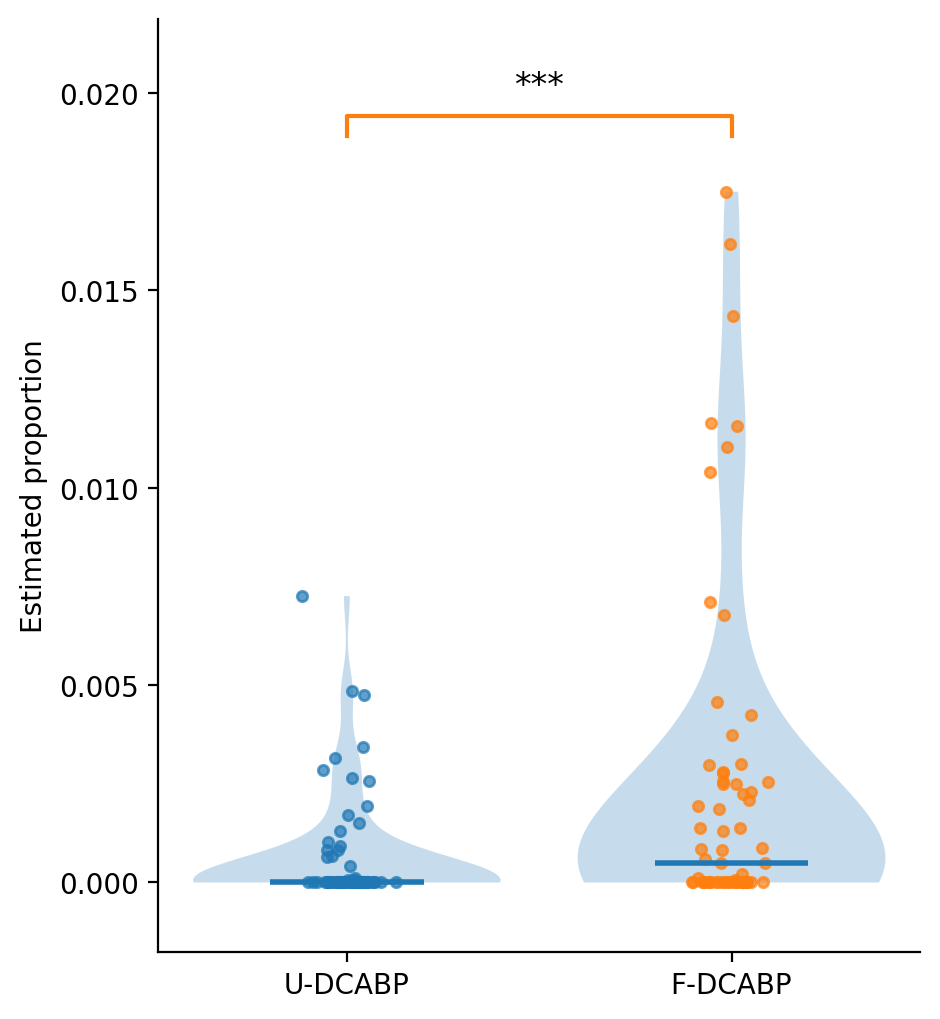

In [16]:
violin_compare(df_, df_.Hyper_DCABP_general, df_['intermediate monocyte'],
               y_label="Estimated proportion",
               title="",
               out_prefix="Monocytes_by_Hypertopic")